# AIML CLZC416 — Mathematical Foundations for Machine Learning
## Assignment 2

**Note on notation / conventions used throughout**

* All optimisation routines (gradient, direction, step size, update) are implemented from scratch.
  Only **NumPy / Pandas / Matplotlib** are used — no `scipy.optimize` or any library that performs the
  line-search / descent step.
* Corrections incorporated from the instructor's clarifications:
  * **Q3** function is $f(x)=x_1^4+16x_2^4-8x_1x_2$ (second term is $x_2^4$).
  * **Q2 part 4** table reports $(w_k,\,A_k,\,g(w_k))$ for the **Adam** iterates, where $A_k=\alpha_t$ is the bias-corrected learning rate.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
np.set_printoptions(precision=6, suppress=True)

---
# Q1 — Steepest Descent with Exact Line Search

$$J(\mathbf{w})=\tfrac12\,\mathbf{w}^{\!\top}\!\begin{bmatrix}4&1\\1&2\end{bmatrix}\mathbf{w}-\begin{bmatrix}1&2\end{bmatrix}\mathbf{w},
\qquad \mathbf{w}_0=\begin{bmatrix}0\\0\end{bmatrix}.$$

Write $J(\mathbf w)=\tfrac12\mathbf w^{\top}A\mathbf w-\mathbf b^{\top}\mathbf w$ with
$A=\begin{bmatrix}4&1\\1&2\end{bmatrix}$ (symmetric, positive-definite) and $\mathbf b=\begin{bmatrix}1\\2\end{bmatrix}$.

**Step 1 — Gradient** &nbsp; $\nabla J(\mathbf w)=A\mathbf w-\mathbf b.$

**Step 2 — Steepest-descent direction** &nbsp; $\mathbf g_t=-\nabla J(\mathbf w_t)=\mathbf b-A\mathbf w_t.$

**Step 3 — Exact line search.** Minimising $\phi(\alpha)=J(\mathbf w_t+\alpha\mathbf g_t)$ gives $\phi'(\alpha)=0$, i.e.
$$\alpha_t=\frac{\mathbf g_t^{\top}\mathbf g_t}{\mathbf g_t^{\top}A\,\mathbf g_t}.$$

**Step 4 — Update** &nbsp; $\mathbf w_{t+1}=\mathbf w_t+\alpha_t\mathbf g_t.$

**Step 5 — Stopping criterion** &nbsp; iterate until $\lVert\nabla J(\mathbf w)\rVert<10^{-6}$ (the `break` test in the loop below).

**Step 6 — Plots** &nbsp; objective $J(\mathbf w)$ vs iteration, and gradient norm $\lVert\nabla J\rVert$ vs iteration (dedicated plots cell).

**Step 7 — Verification** &nbsp; check numerically that $\mathbf g_t^{\top}\nabla J(\mathbf w_{t+1})\approx 0$.

**Step 8 — Report** &nbsp; the optimal solution and total number of iterations.

The exact minimiser is $\mathbf w^\star=A^{-1}\mathbf b=\begin{bmatrix}0\\1\end{bmatrix}$, with $J(\mathbf w^\star)=-1$.


In [19]:
# ---- Q1: Steepest Descent with Exact Line Search ----
A = np.array([[4.0, 1.0],
              [1.0, 2.0]])
b = np.array([1.0, 2.0])

def J(w):    return 0.5 * w @ A @ w - b @ w      # objective
def grad(w): return A @ w - b                    # Step 1: gradient = A w - b

w   = np.array([0.0, 0.0])   # w0
tol = 1e-6
max_iter = 1000

J_hist, gnorm_hist, ortho_hist = [], [], []

for t in range(max_iter):
    g   = grad(w)                                 # Step 1: gradient at w_t
    gnorm = np.linalg.norm(g)
    J_hist.append(J(w))
    gnorm_hist.append(gnorm)
    if gnorm < tol:                               # Step 5: stopping test ||grad|| < 1e-6
        break
    d = -g                                        # Step 2: steepest descent direction g_t
    alpha = (d @ d) / (d @ A @ d)                 # Step 3: exact line-search step size
    w_new = w + alpha * d                         # Step 4: parameter update
    ortho_hist.append(d @ grad(w_new))            # Step 7: check g_t^T grad(w_{t+1})
    w = w_new

# Step 8: report
print("Optimal solution   w* =", w)
print("Analytic  A^{-1} b =", np.linalg.solve(A, b))
print("J(w*)              =", J(w))
print("Total iterations   =", t)
print("Final ||grad||     =", gnorm_hist[-1])
print("max |g_t^T grad(w_{t+1})| =", np.max(np.abs(ortho_hist)))

Optimal solution   w* = [0. 1.]
Analytic  A^{-1} b = [0. 1.]
J(w*)              = -0.999999999999937
Total iterations   = 20
Final ||grad||     = 5.610035624716221e-07
max |g_t^T grad(w_{t+1})| = 0.0


**7. Numerical verification of $\mathbf g_t^{\top}\nabla J(\mathbf w_{t+1})\approx 0$.**
For a quadratic with exact line search, consecutive gradients are orthogonal, so
$\mathbf g_t^{\top}\nabla J(\mathbf w_{t+1})=0$ up to round-off (printed above).

**Step 6 — Plots:** objective $J(\mathbf w)$ vs iteration, and gradient norm $\lVert\nabla J\rVert$ vs iteration.

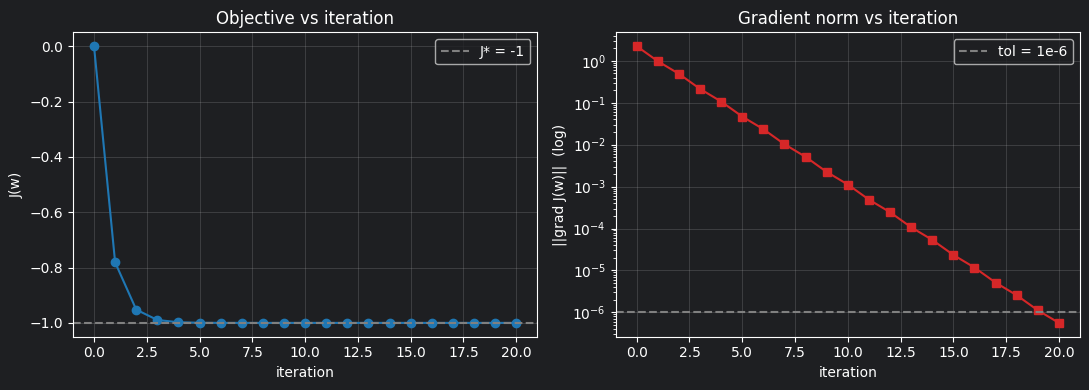

In [20]:
# ---- Q1: plots ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(len(J_hist)), J_hist, 'o-', color='tab:blue')
ax[0].axhline(-1.0, ls='--', color='grey', label='J* = -1')
ax[0].set_xlabel('iteration'); ax[0].set_ylabel('J(w)')
ax[0].set_title('Objective vs iteration'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].semilogy(range(len(gnorm_hist)), gnorm_hist, 's-', color='tab:red')
ax[1].axhline(1e-6, ls='--', color='grey', label='tol = 1e-6')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('||grad J(w)||  (log)')
ax[1].set_title('Gradient norm vs iteration'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**8. Report.** Optimal solution $\mathbf w^\star=(0,\,1)$, objective $J(\mathbf w^\star)=-1$, reached in
**20 iterations** (final $\lVert\nabla J\rVert<10^{-6}$). The orthogonality check $\mathbf g_t^{\top}\nabla J(\mathbf w_{t+1})$
is zero to machine precision, confirming the exact line search.

---
# Q2 — Gradient Descent vs Adam on $g(w)=(w-1.5)^2$

$g(w)=(w-1.5)^2,\; w\in[1,2]$, so $g'(w)=2(w-1.5)$; the minimiser is $w^\star=1.5$.

### Part 1 — Gradient-descent iteration (learning rate $\eta=0.2$, $w_0=2$)
$$w_{k+1}=w_k-\eta\,g'(w_k)=w_k-0.2\cdot 2(w_k-1.5)=w_k-0.4\,(w_k-1.5).$$
Equivalently $w_{k+1}=0.6\,w_k+0.6$, a contraction toward $1.5$ (factor $0.6$ per step).


In [21]:
# ---- Q2 Part 2: Gradient Descent, 10 iterations ----
g_val  = lambda w: (w - 1.5)**2
g_grad = lambda w: 2.0 * (w - 1.5)

eta, w = 0.2, 2.0
rows = [(0, w, g_val(w))]
for k in range(1, 11):
    w = w - eta * g_grad(w)
    rows.append((k, w, g_val(w)))

gd = pd.DataFrame(rows, columns=["k", "w_k", "g(w_k)"])
gd

,k,w_k,g(w_k)
0,0,2.000000,0.250000
1,1,1.800000,0.090000
2,2,1.680000,0.032400
3,3,1.608000,0.011664
4,4,1.564800,0.004199
5,5,1.538880,0.001512
6,6,1.523328,0.000544
7,7,1.513997,0.000196
8,8,1.508398,0.000071
9,9,1.505039,0.000025


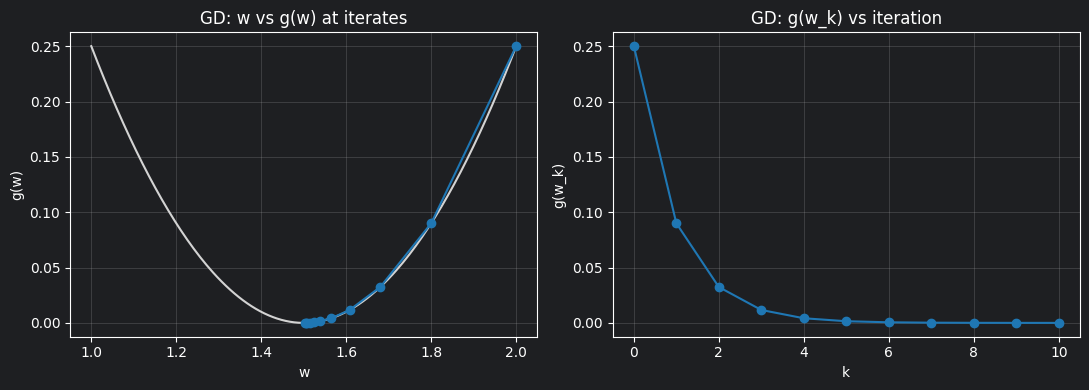

In [22]:
# ---- Q2 Part 2: convergence plot ----
ws = np.linspace(1, 2, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ws, g_val(ws), color='lightgrey')
ax[0].plot(gd["w_k"], gd["g(w_k)"], 'o-', color='tab:blue')
ax[0].set_xlabel('w'); ax[0].set_ylabel('g(w)'); ax[0].set_title('GD: w vs g(w) at iterates')
ax[0].grid(alpha=.3)
ax[1].plot(gd["k"], gd["g(w_k)"], 'o-', color='tab:blue')
ax[1].set_xlabel('k'); ax[1].set_ylabel('g(w_k)'); ax[1].set_title('GD: g(w_k) vs iteration')
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Part 3 — Adam iteration (bias-corrected)

With learning rate $\alpha=0.2$, first-moment decay $\rho_f=0.9$, second-moment decay $\rho=0.999$, $w_0=2$:

$$s_t=\rho_f\,s_{t-1}+(1-\rho_f)\,g_t,\qquad r_t=\rho\,r_{t-1}+(1-\rho)\,g_t^{2},$$

Using the **efficient (bias-corrected)** form, the effective learning rate at step $t$ is
$$\boxed{\;\alpha_t=\alpha\,\dfrac{\sqrt{1-\rho^{\,t}}}{1-\rho_f^{\,t}}\;},\qquad
w_t=w_{t-1}-\alpha_t\,\dfrac{s_t}{\sqrt{r_t}+\epsilon}.$$

This is algebraically identical to updating with the bias-corrected moments
$\hat s_t=s_t/(1-\rho_f^t)$, $\hat r_t=r_t/(1-\rho^t)$. The table below reports $A_k\equiv\alpha_t$.


In [23]:
# ---- Q2 Part 4: Adam, 10 iterations ----
alpha, rho, rho_f, eps = 0.2, 0.999, 0.9, 1e-8
w, s, r = 2.0, 0.0, 0.0
rows = [(0, w, np.nan, g_val(w))]          # k=0: initial point, no step taken yet -> no alpha_t
for t in range(1, 11):
    g  = g_grad(w)
    s  = rho_f * s + (1 - rho_f) * g        # 1st moment
    r  = rho   * r + (1 - rho)   * g**2     # 2nd moment
    a_t = alpha * np.sqrt(1 - rho**t) / (1 - rho_f**t)   # bias-corrected LR = A_k
    w  = w - a_t * s / (np.sqrt(r) + eps)
    rows.append((t, w, a_t, g_val(w)))
adam = pd.DataFrame(rows, columns=["k", "w_k", "A_k (alpha_t)", "g(w_k)"])
# k=0 has no alpha_t (no step yet) -> show a dash instead of NaN
adam.style.format({"w_k": "{:.6f}", "A_k (alpha_t)": "{:.6f}", "g(w_k)": "{:.6f}"},
                  na_rep="—").hide(axis="index")

k,w_k,A_k (alpha_t),g(w_k)
0,2.000000,—,0.250000
1,1.800000,0.063246,0.090000
2,1.608502,0.047063,0.011773
3,1.439583,0.040402,0.003650
4,1.313724,0.036754,0.034699
5,1.244792,0.034500,0.065131
6,1.229383,0.033022,0.073233
7,1.254674,0.032026,0.060185
8,1.307569,0.031354,0.037030
9,1.376950,0.030912,0.015141


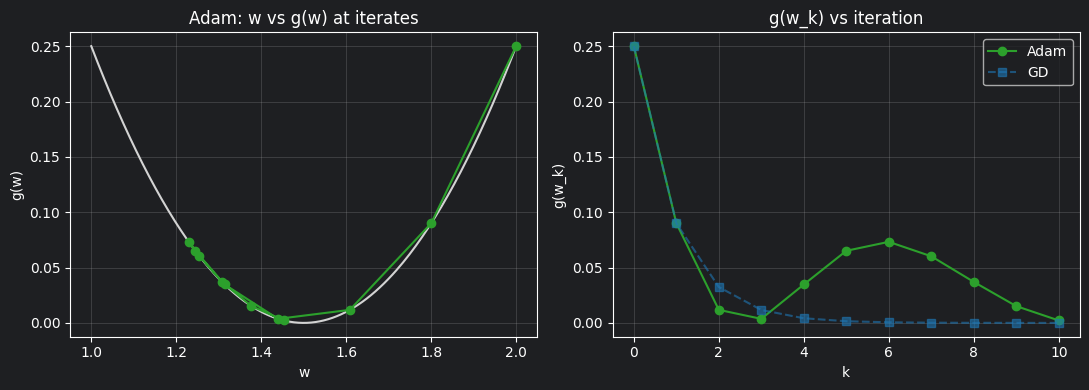

In [24]:
# ---- Q2 Part 4: convergence plot ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ws, g_val(ws), color='lightgrey')
ax[0].plot(adam["w_k"], adam["g(w_k)"], 'o-', color='tab:green')
ax[0].set_xlabel('w'); ax[0].set_ylabel('g(w)'); ax[0].set_title('Adam: w vs g(w) at iterates')
ax[0].grid(alpha=.3)
ax[1].plot(adam["k"], adam["g(w_k)"], 'o-', color='tab:green', label='Adam')
ax[1].plot(gd["k"], gd["g(w_k)"], 's--', color='tab:blue', alpha=.6, label='GD')
ax[1].set_xlabel('k'); ax[1].set_ylabel('g(w_k)'); ax[1].set_title('g(w_k) vs iteration')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Observation.** Plain GD contracts monotonically toward $1.5$ (factor $0.6$/step). Adam builds up
momentum in $s_t$ and *overshoots* past $1.5$ (down to $\approx1.23$ around $k=6$) before curving back —
the classic momentum behaviour — while its effective step $\alpha_t$ decays from $0.063$ toward $\approx0.03$.

---
# Q3 — AdaGrad vs RMSProp on $f(x)=x_1^4+16x_2^4-8x_1x_2$

Gradient:
$$\nabla f=\begin{bmatrix}4x_1^3-8x_2\\[2pt]64x_2^3-8x_1\end{bmatrix},\qquad
\text{Hessian }H=\begin{bmatrix}12x_1^2&-8\\-8&192x_2^2\end{bmatrix}.$$

### Part 1 — Is constant-step gradient descent a good approach?

**No.** The curvature along the two axes is grossly unequal. At the start $(1,1)$ the diagonal Hessian
entries are $\partial^2 f/\partial x_1^2=12$ and $\partial^2 f/\partial x_2^2=192$ — a ratio of **16:1**, and it
stays large near the minimum $(1,0.5)$ where they are $12$ and $48$ (ratio $4:1$). A single constant step $\alpha$
must satisfy the stability bound $\alpha<2/L$ set by the **large**-curvature direction $x_2$; that same $\alpha$
is then far too small for the **flat** $x_1$ direction. The result is the textbook zig-zag of steepest descent on
an ill-conditioned problem: fast oscillation across the steep $x_2$ valley and crawling progress along $x_1$.
Because the curvature also *changes* with position (the quartic stiffens as $|x|$ grows), no single constant step
is uniformly good — a **per-coordinate adaptive** step (AdaGrad / RMSProp) is the appropriate remedy.


In [25]:
# ---- Q3: function, gradient, and a reusable adaptive-method runner ----
f = lambda x: x[0]**4 + 16*x[1]**4 - 8*x[0]*x[1]
grad_f = lambda x: np.array([4*x[0]**3 - 8*x[1],
                             64*x[1]**3 - 8*x[0]])

def run(method, alpha=0.01, rho=0.9, eps=0.0, n=20):
    x = np.array([1.0, 1.0])          # initial point (1,1)
    Aacc = np.array([0.0, 0.0])       # accumulator A
    rows = []
    for k in range(1, n + 1):
        g = grad_f(x)                             # gradient at current x^(k-1)
        if method == "adagrad":
            Aacc = Aacc + g**2                    # running SUM of squared grads
        else:  # rmsprop
            Aacc = rho * Aacc + (1 - rho) * g**2  # EMA of squared grads
        x = x - alpha * g / (np.sqrt(Aacc) + eps) # per-coordinate update
        rows.append([k, x[0], x[1], g[0], g[1], Aacc[0], Aacc[1]])
    cols = ["k", "x1^(k)", "x2^(k)", "f_x1^(k)", "f_x2^(k)", "A_x1^(k)", "A_x2^(k)"]
    return pd.DataFrame(rows, columns=cols)



### Part 2 — AdaGrad (20 iterations, $\alpha=0.01$, $\epsilon=0$)

In [26]:
ada = run("adagrad", alpha=0.01, eps=0.0, n=20)
ada.style.format({c: "{:.6f}" for c in ada.columns[1:]})

,k,x1^(k),x2^(k),f_x1^(k),f_x2^(k),A_x1^(k),A_x2^(k)
0,1,1.010000,0.990000,-4.000000,56.000000,16.000000,3136.000000
1,2,1.016886,0.983057,-3.798796,54.019136,30.430851,6054.067054
2,3,1.022413,0.977452,-3.658382,52.666727,43.814608,8827.851200
3,4,1.027134,0.972639,-3.544584,51.588349,56.378681,11489.208949
4,5,1.031306,0.968365,-3.446590,50.672050,68.257665,14056.865552
5,6,1.035072,0.964488,-3.359370,49.865783,79.543033,16543.461898
6,7,1.038524,0.960919,-3.280105,49.140419,90.302119,18958.242688
7,8,1.041722,0.957598,-3.207028,48.477727,100.587144,21308.332748
8,9,1.044709,0.954482,-3.138947,47.865413,110.440131,23599.430504
9,10,1.047517,0.951540,-3.075013,47.294722,119.895834,25836.221235


### Part 3 — RMSProp (20 iterations, $\alpha=0.01$, $\rho=0.9$, $\epsilon=0$)

In [27]:
rms = run("rmsprop", alpha=0.01, rho=0.9, eps=0.0, n=20)
rms.style.format({c: "{:.6f}" for c in rms.columns[1:]})

,k,x1^(k),x2^(k),f_x1^(k),f_x2^(k),A_x1^(k),A_x2^(k)
0,1,1.031623,0.968377,-4.000000,56.000000,1.600000,313.600000
1,2,1.052570,0.946735,-3.355418,49.865421,2.565883,530.896019
2,3,1.068947,0.929246,-2.909297,45.887683,3.155696,688.374366
3,4,1.082589,0.914139,-2.548241,42.802094,3.489479,802.738858
4,5,1.094317,0.900610,-2.237940,40.228850,3.641369,884.301010
5,6,1.104574,0.888219,-1.962982,37.996475,3.662562,940.244120
6,7,1.113625,0.876692,-1.715067,36.011110,3.590451,975.899714
7,8,1.121639,0.865847,-1.489239,34.215139,3.453189,995.377318
8,9,1.128728,0.855557,-1.282355,32.570376,3.272314,1001.922524
9,10,1.134968,0.845729,-1.092338,31.050081,3.064403,998.141024


AdaGrad  : f after 20 iters = 5.237693   (x = 1.069415, 0.928068)
RMSProp  : f after 20 iters = 0.145551   (x = 1.158030, 0.762638)
True minimum: f = -2 at (1, 0.5)


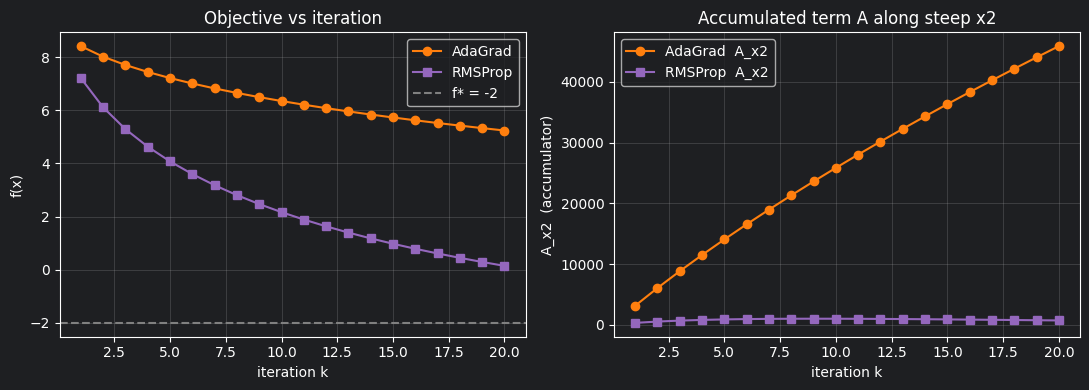

In [28]:
# ---- Q3: objective value along each trajectory (for the comparison) ----
fa = [f(np.array([r["x1^(k)"], r["x2^(k)"]])) for _, r in ada.iterrows()]
fr = [f(np.array([r["x1^(k)"], r["x2^(k)"]])) for _, r in rms.iterrows()]
print(f"AdaGrad  : f after 20 iters = {fa[-1]:.6f}   (x = {ada.iloc[-1]['x1^(k)']:.6f}, {ada.iloc[-1]['x2^(k)']:.6f})")
print(f"RMSProp  : f after 20 iters = {fr[-1]:.6f}   (x = {rms.iloc[-1]['x1^(k)']:.6f}, {rms.iloc[-1]['x2^(k)']:.6f})")
print(f"True minimum: f = -2 at (1, 0.5)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ada["k"], fa, 'o-', label='AdaGrad', color='tab:orange')
ax[0].plot(rms["k"], fr, 's-', label='RMSProp', color='tab:purple')
ax[0].axhline(-2, ls='--', color='grey', label='f* = -2')
ax[0].set_xlabel('iteration k'); ax[0].set_ylabel('f(x)'); ax[0].set_title('Objective vs iteration')
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ada["k"], ada["A_x2^(k)"], 'o-', label='AdaGrad  A_x2', color='tab:orange')
ax[1].plot(rms["k"], rms["A_x2^(k)"], 's-', label='RMSProp  A_x2', color='tab:purple')
ax[1].set_xlabel('iteration k'); ax[1].set_ylabel('A_x2  (accumulator)'); ax[1].set_title('Accumulated term A along steep x2')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Part 4 — Which performs better, and why?

**RMSProp performs better.** After 20 iterations RMSProp reaches $f\approx0.15$ (moving steadily toward the
minimum $f^\star=-2$ at $(1,0.5)$), whereas AdaGrad stalls at $f\approx5.24$, having barely moved from the start.

The reason lies entirely in how the accumulated term $A$ behaves along the **steep $x_2$ direction**
(curvature $192x_2^2$, giving a large initial gradient $f_{x_2}=56$):

* **AdaGrad** accumulates a *monotonically growing sum* of squared gradients:
  $A_{x_2}$ climbs from $3136$ (k=1) to $\approx45{,}900$ (k=20). Since the step is $\alpha\,g/\sqrt{A}$,
  the effective learning rate $\alpha/\sqrt{A_{x_2}}$ decays like $1/\sqrt{k}$ and never recovers. The large
  early $x_2$-gradient permanently inflates $A_{x_2}$, so $x_2$ freezes ($0.99\to0.93$ over 20 steps) long
  before reaching $0.5$ — AdaGrad's aggressive, non-forgetting decay is fatal on this stiff coordinate.
* **RMSProp** uses an *exponential moving average* ($\rho=0.9$), so $A_{x_2}$ stays **bounded/adaptive**
  (it settles around $700$–$800$, even shrinking as the gradient falls). The effective step therefore does
  **not** collapse; $x_2$ keeps descending ($0.97\to0.76$) and $f$ falls by an order of magnitude more than AdaGrad.

**In short:** on this ill-conditioned quartic, AdaGrad's ever-growing $A$ kills the learning rate in the very
direction that needs sustained progress, while RMSProp's forgetting factor keeps $A$ — and hence the step —
responsive throughout the 20 iterations. Hence RMSProp is the better optimiser here.
